# Residual Quanvolutional Neural Network (ResQuNN)

This notebook implements:
- Trainable 4-qubit quanvolutional layers
- Angle encoding with RY gates
- Trainable RX gates
- Nearest-neighbor CNOT entanglement
- Two-layer ResQuNN with O1 + O2 residual connection
- Classical post-processing head
- PyTorch + PennyLane training loop


In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np


## Quantum circuit used in the quanvolutional layer

In [53]:
n_qubits = 4
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface='torch', diff_method='parameter-shift')
def quanv_circuit(inputs, weights, depth):
    # Angle encoding
    for i in range(4):
        qml.RY(inputs[i], wires=i)

    for d in range(depth):
        for i in range(4):
            qml.RX(weights[d, i], wires=i)

        for i in range(3):
            qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliZ(i)) for i in range(4)]


In [ ]:
class QuanvLayer(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.depth = depth
        self.weights = nn.Parameter(0.01 * torch.randn(depth, 4))

    def forward(self, x):
        batch_size = x.shape[0]
        outputs = []

        for b in range(batch_size):
            img = x[b, 0]
            rows = []

            for i in range(0, img.shape[0], 2):
                cols = []
                for j in range(0, img.shape[1], 2):
                    patch = img[i:i+2, j:j+2].reshape(-1)
                    q_out = quanv_circuit(patch, self.weights, self.depth)
                    cols.append(torch.mean(torch.stack(q_out)))

                rows.append(torch.stack(cols))

            outputs.append(torch.stack(rows))

        return torch.stack(outputs).unsqueeze(1)


## ResQuNN architecture (O1 + O2 residual configuration)

In [ ]:
class ResQuNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        # QCL1 depth=4 (paper)
        self.qcl1 = QuanvLayer(depth=4)

        # QCL2 depth=1 (paper)
        self.qcl2 = QuanvLayer(depth=1)

        self.fc = nn.Linear(49, n_classes)

    def forward(self, x):
        o1 = self.qcl1(x)

        o2 = self.qcl2(o1)

        o2_up = F.interpolate(
        o2,
        size=(14,14),
        mode="nearest"
    )
        residual = o1+ o2_up
        residual = residual.reshape(residual.shape[0], -1)

        residual = residual.float()
        
        return self.fc(residual)


## MNIST subset used in the paper

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)
n_train_samples=100
n_test_samples=100

train_indices = list(range(n_train_samples))
test_indices  = list(range(n_train_samples, n_train_samples+n_test_samples))

train_subset = Subset(train_dataset, train_indices)
test_subset  = Subset(train_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=1, shuffle=False)

## Training loop

In [ ]:
model = ResQuNN(n_classes=10)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 15
from time import perf_counter
train_losses = []
for epoch in range(epochs):

    start = perf_counter()
    model.train()
    running_loss = 0
    epoch_loss=0

    for images, labels in train_loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)


    print(f'Epoch {epoch+1}: loss={running_loss/len(train_loader):.4f}')


Epoch 1: loss=3.4042
Epoch 2: loss=2.4661
Epoch 3: loss=2.3239
Epoch 4: loss=2.2568
Epoch 5: loss=2.1923
Epoch 6: loss=2.1117
Epoch 7: loss=2.0207
Epoch 8: loss=1.9126
Epoch 9: loss=1.8343
Epoch 10: loss=1.7359
Epoch 11: loss=1.6734
Epoch 12: loss=1.5959
Epoch 13: loss=1.5411
Epoch 14: loss=1.4890
Epoch 15: loss=1.4204


# Plot of training process

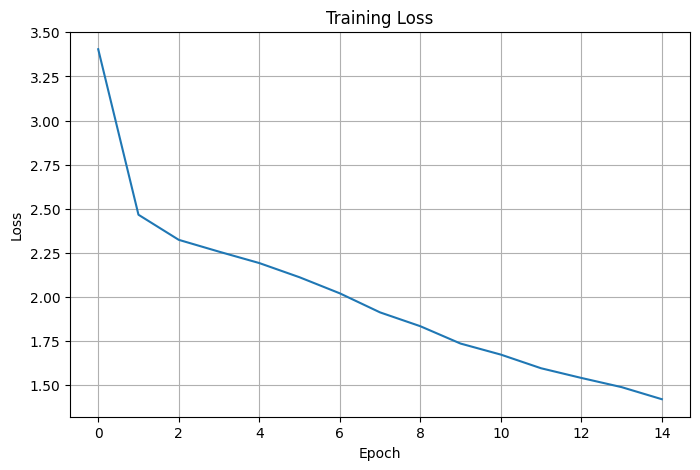

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

# Test set metrics

In [59]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        logits = model(images)

        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

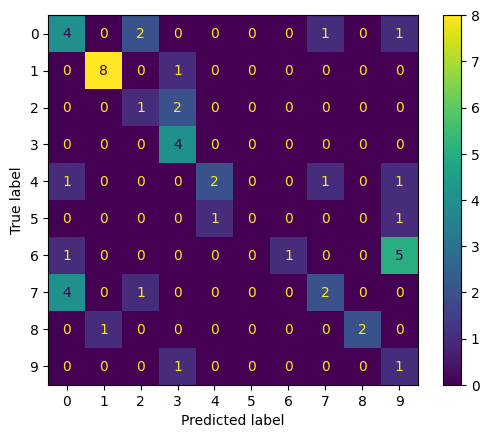

              precision    recall  f1-score   support

           0       0.40      0.50      0.44         8
           1       0.89      0.89      0.89         9
           2       0.25      0.33      0.29         3
           3       0.50      1.00      0.67         4
           4       0.67      0.40      0.50         5
           5       0.00      0.00      0.00         2
           6       1.00      0.14      0.25         7
           7       0.50      0.29      0.36         7
           8       1.00      0.67      0.80         3
           9       0.11      0.50      0.18         2

    accuracy                           0.50        50
   macro avg       0.53      0.47      0.44        50
weighted avg       0.62      0.50      0.49        50



/Users/leopoldomorante/QuiskitLeo/anaconda3/envs/quantum_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leopoldomorante/QuiskitLeo/anaconda3/envs/quantum_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/leopoldomorante/QuiskitLeo/anaconda3/envs/quantum_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(10))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10))
)

disp.plot()
plt.show()
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds
    )
)

### Notes
- QCL1 uses depth 4.
- QCL2 uses depth 1.
- 2x2 kernels produce 4 encoded features.
- Angle encoding uses RY rotations.
- Trainable parameters are RX angles.
- Entanglement uses nearest-neighbor CNOT gates.
- Residual connection shown here is O1 + O2, the configuration highlighted in the paper as enabling gradient propagation through both quanvolutional layers.